In [2]:
# ============================================================
# ✅ IMPORTS
# ============================================================
import os
import zipfile
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D, BatchNormalization
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam
from tensorflow.keras import regularizers
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import pandas as pd

In [3]:
# ============================================================
# ✅ PATH SETUP
# ============================================================
TRAIN_DIR = "/kaggle/input/datasets/briscdataset/brisc2025/brisc2025/classification_task/train"
OUTPUT_DIR = "/kaggle/working/densenet121_results"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# ============================================================
# ✅ DATA GENERATORS
# ============================================================
batch_size = 16
target_size = (224, 224)

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    width_shift_range=0.15,
    height_shift_range=0.15,
    shear_range=0.15,
    zoom_range=0.25,
    brightness_range=[0.85, 1.15],
    horizontal_flip=True,
    validation_split=0.2
)

train_generator = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=target_size,
    batch_size=batch_size,
    class_mode='sparse',
    subset='training',
    shuffle=True,
    seed=42
)

val_generator = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=target_size,
    batch_size=batch_size,
    class_mode='sparse',
    subset='validation',
    shuffle=False,
    seed=42
)

num_classes = len(train_generator.class_indices)
class_names = list(train_generator.class_indices.keys())

Found 4002 images belonging to 4 classes.
Found 998 images belonging to 4 classes.


In [ ]:
# ============================================================
# ✅ MODEL: DenseNet121
# ============================================================
base_model = DenseNet121(weights='imagenet',
                         include_top=False,
                         input_shape=(224,224,3))

# Freeze 60% layers
freeze_until = int(len(base_model.layers) * 0.6)
for layer in base_model.layers[:freeze_until]:
    layer.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = BatchNormalization()(x)
x = Dense(256, activation='relu',
          kernel_regularizer=regularizers.l2(1e-4))(x)
x = Dropout(0.4)(x)
output = Dense(num_classes, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=output)

model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

I0000 00:00:1772340022.482545      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1772340022.488666      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zero_padding2d      │ (None, 230, 230,  │          0 │ input_layer[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,408 │ zero_padding2d[0… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zero_padding2d_1    │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1               │ (None, 56, 56,    │          0 │ zero_padding2d_1… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │        256 │ pool1[0][0]       │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_relu │ (None, 56, 56,    │          0 │ conv2_block1_0_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      8,192 │ conv2_block1_0_r… │
│ (Conv2D)            │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        512 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,864 │ conv2_block1_1_r… │
│ (Conv2D)            │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_concat │ (None, 56, 56,    │          0 │ pool1[0][0],      │
│ (Concatenate)       │ 96)               │            │ conv2_block1_2_c… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_0_bn   │ (None, 56, 56,    │        384 │ conv2_block1_con… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_0_relu │ (None, 56, 56,    │          0 │ conv2_block2_0_b… │
│ (Activation)        │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_1_conv │ (None, 56, 56,    │     12,288 │ conv2_block2_0_r

 Total params: 7,305,028 (27.87 MB)

 Trainable params: 4,064,260 (15.50 MB)

 Non-trainable params: 3,240,768 (12.36 MB)

In [5]:
# ============================================================
# ✅ CALLBACKS
# ============================================================
early_stop = EarlyStopping(monitor='val_loss',
                           patience=10,
                           restore_best_weights=True)

reduce_lr = ReduceLROnPlateau(monitor='val_loss',
                              factor=0.5,
                              patience=4,
                              min_lr=1e-6)

# ============================================================
# ✅ TRAINING
# ============================================================
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=100,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/100


I0000 00:00:1772340064.423314     140 service.cc:152] XLA service 0x7ad764003710 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1772340064.423368     140 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1772340064.423375     140 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1772340070.477944     140 cuda_dnn.cc:529] Loaded cuDNN version 91002


  1/251 ━━━━━━━━━━━━━━━━━━━━ 5:15:12 76s/step - accuracy: 0.1875 - loss: 2.0785

I0000 00:00:1772340111.311206     140 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


251/251 ━━━━━━━━━━━━━━━━━━━━ 237s 645ms/step - accuracy: 0.7099 - loss: 0.7597 - val_accuracy: 0.8958 - val_loss: 0.3500 - learning_rate: 1.0000e-04
Epoch 2/100
251/251 ━━━━━━━━━━━━━━━━━━━━ 66s 261ms/step - accuracy: 0.9160 - loss: 0.2557 - val_accuracy: 0.9118 - val_loss: 0.2746 - learning_rate: 1.0000e-04
Epoch 3/100
251/251 ━━━━━━━━━━━━━━━━━━━━ 65s 261ms/step - accuracy: 0.9444 - loss: 0.1962 - val_accuracy: 0.9399 - val_loss: 0.2328 - learning_rate: 1.0000e-04
Epoch 4/100
251/251 ━━━━━━━━━━━━━━━━━━━━ 65s 259ms/step - accuracy: 0.9531 - loss: 0.1692 - val_accuracy: 0.9279 - val_loss: 0.3355 - learning_rate: 1.0000e-04
Epoch 5/100
251/251 ━━━━━━━━━━━━━━━━━━━━ 66s 261ms/step - accuracy: 0.9640 - loss: 0.1397 - val_accuracy: 0.9208 - val_loss: 0.2630 - learning_rate: 1.0000e-04
Epoch 6/100
251/251 ━━━━━━━━━━━━━━━━━━━━ 67s 266ms/step - accuracy: 0.9691 - loss: 0.1215 - val_accuracy: 0.9439 - val_loss: 0.2272 - learning_rate: 1.0000e-04
Epoch 7/100
251/251 ━━━━━━━━━━━━━━━━━━━━ 67s 265ms/

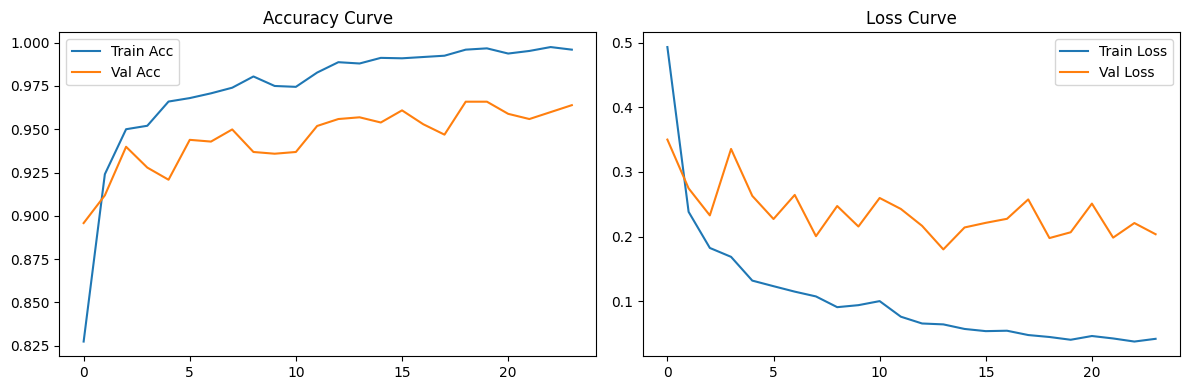

✅ Training curves saved successfully.


In [6]:
# ============================================================
# ✅ TRAINING CURVES
# ============================================================
plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.title('Accuracy Curve')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Loss Curve')
plt.legend()

curve_path = os.path.join(OUTPUT_DIR, "training_curves.png")
plt.tight_layout()
plt.savefig(curve_path)
plt.show()

print("✅ Training curves saved successfully.")

In [7]:
# ============================================================
# ✅ EVALUATION
# ============================================================
val_generator.reset()
pred_probs = model.predict(val_generator)
y_pred = np.argmax(pred_probs, axis=1)
y_true = val_generator.classes

acc = accuracy_score(y_true, y_pred)
prec = precision_score(y_true, y_pred, average='macro')
rec = recall_score(y_true, y_pred, average='macro')
f1 = f1_score(y_true, y_pred, average='macro')

print("\nClassification Report:\n")
print(classification_report(y_true, y_pred, target_names=class_names))

print(f"\n✅ Accuracy:  {acc*100:.2f}%")
print(f"✅ Precision: {prec*100:.2f}%")
print(f"✅ Recall:    {rec*100:.2f}%")
print(f"✅ F1-Score:  {f1*100:.2f}%")

63/63 ━━━━━━━━━━━━━━━━━━━━ 34s 366ms/step

Classification Report:

              precision    recall  f1-score   support

      glioma       0.99      0.96      0.97       229
  meningioma       0.93      0.92      0.92       265
    no_tumor       0.94      1.00      0.97       213
   pituitary       0.97      0.96      0.96       291

    accuracy                           0.96       998
   macro avg       0.96      0.96      0.96       998
weighted avg       0.96      0.96      0.96       998


✅ Accuracy:  95.59%
✅ Precision: 95.66%
✅ Recall:    95.80%
✅ F1-Score:  95.70%


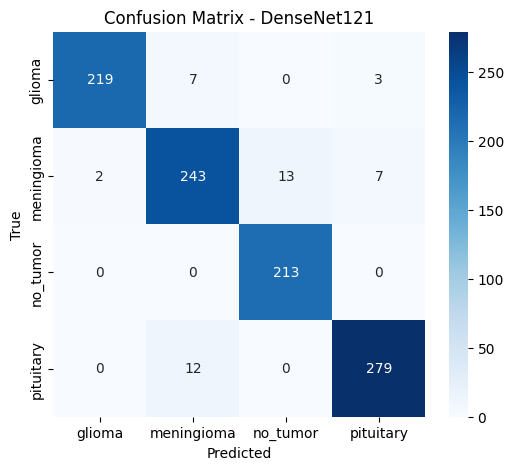

In [8]:
# ============================================================
# ✅ CONFUSION MATRIX
# ============================================================
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix - DenseNet121")

cm_path = os.path.join(OUTPUT_DIR, "confusion_matrix.png")
plt.savefig(cm_path)
plt.show()

In [9]:
# ============================================================
# ✅ SAVE METRICS & PREDICTIONS
# ============================================================
report = classification_report(
    y_true, y_pred,
    target_names=class_names,
    output_dict=True
)

metrics_df = pd.DataFrame(report).transpose()
metrics_df.to_csv(os.path.join(OUTPUT_DIR, "metrics.csv"))

pred_df = pd.DataFrame({
    "true_label_index": y_true,
    "predicted_label_index": y_pred,
    "true_label": [class_names[i] for i in y_true],
    "predicted_label": [class_names[i] for i in y_pred]
})
pred_df.to_csv(os.path.join(OUTPUT_DIR, "predictions.csv"), index=False)

np.save(os.path.join(OUTPUT_DIR, "confusion_matrix.npy"), cm)

# ============================================================
# ✅ ZIP RESULTS
# ============================================================
zip_path = "/kaggle/working/densenet121_results.zip"
with zipfile.ZipFile(zip_path, 'w', zipfile.ZIP_DEFLATED) as zipf:
    for file in os.listdir(OUTPUT_DIR):
        zipf.write(os.path.join(OUTPUT_DIR, file), file)

print(f"\n📦 Results saved to: {zip_path}")


📦 Results saved to: /kaggle/working/densenet121_results.zip
